<a href="https://colab.research.google.com/github/AlerAlfredo/Analysis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


Notas generales de primera vista:

1. Las columnas **plan** y **plan_name** deben de homogeneizarse
2. El dataset **plans** no estima realizar modificaciones
3. El dataset **users** contienen en su columna **city** **469** valores nulos así como sentinels y **churn_date** solo reconoce 466 registros.
4. El dataset **usage** tiene datos nulos en las columnas **date**, **duration** y **length**
5. Será imperativo cambiar el tipo de datos en las columnas de **date** a tipo fecha.

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print(usage.isna().mean()) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


In [ ]:
# validando nulos de dataset usage
usage[['duration','length']].isna().groupby(usage['type']).mean().sort_values(by='duration',ascending=False)

,duration,length
type,,
text,0.999276,0.00000
call,0.000000,0.99933


Se puede interpretar que el valor faltante de ambas columnas ('duration' y 'length') son de tipo MNAR (Missing not at Random) ya que al observar la relación con la columna 'type', ésta no ocurre al azar, sino que corresponde a una ausencia estructural dictada por la lógica del negocio. Registros de tipo text tienen longitud y no duración, mientras que registros de tipo call poseen duración pero no longitud.

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  a) La columna **city** del dataset "users" presenta **469** valores nulos que representa un **11%**

  b) La columna **churn_date** del dataset "users" presenta **3534** valores nulos que representa un **88%**

  c) La columna **date** del dataset "usage" presenta **50** valores nulos que representa un **0.1%**

  d) La columna **duration** del dataset "usage" presenta **22076** valores nulos que representa un **55%**

  e) La columna **length** del dataset "usage" presenta **17896** valores nulos que representa un **45%**

- Indica qué harías: ¿imputar, eliminar, ignorar?

  a) Sugiero investigar **city** para realizar su correcta imputación, columna con dato importante.

  b) Sugiero eliminar **churn_date** debido a que los clientes que ya no pertenecen a ConnectaTel, no son objeto del análisis.

  c) Sugiero dejar como nulos los valores de **date** debido a que solo representan un 0.1%

  d) Sugiero imputar con cero (0) **duration** debido a que es útil conocer la duración de llamada para determinar su costo total.

  e) Sugiero imputar con cero (0 ) **length** debido a que sirve para determinar el cálculo de costo de mensajes.

   

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users

numeric_users = ['user_id','age']
users[numeric_users].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# sumar la totalidad de sentinels (-999) en la columna age
users['age'].isin([-999]).sum()

55

- La columna `user_id` muestra una distribución estable, su promedio representa el valor típico y hay poca variabilidad en los datos.
- La columna `age` presenta outliers que mueven el promedio a la izquierda respecto a la mediana que se puede explicar por sentinels (-999).

In [ ]:
# explorar columnas numéricas de usage
numeric_usage = ['id','user_id', 'duration','length']
usage[numeric_usage].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` se presentan estables y homegéneas, sus promedios son iguales a sus medianas y hay poca variabilidad.
- Las columnas `duration` y `length` presentan sesgo a la derecha por valores máximos atípicos. Hay valores nulos (explicado por la lógica del negocio) y mínimos en cero (probablemente por llamadas o mensajes que no se llevaron a cabo).

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


In [ ]:
users['city'].nunique

<bound method IndexOpsMixin.nunique of 0       Medellín
1              ?
2           CDMX
3         Bogotá
4            GDL
          ...   
3995    Medellín
3996    Medellín
3997      Bogotá
3998      Bogotá
3999      Bogotá
Name: city, Length: 4000, dtype: object>

In [ ]:
# sumar la totalidad de sentinels (?) en la columna city
users['city'].isin(['?']).sum()

96

- La columna `city` presenta valores nulos, tiene 7 ciudades y la más frecuente es Bogotá. Así también, presenta sentinels **'?'**
- La columna `plan` contiene 2 planes y el más frecuente es el plan básico.

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` muestra dos tipos de servicio (text y call) siendo text el tipo más frecuente.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

  a) En la columna **age** se visualizan **sentinels** (-999)

  b) En la columna **city** se visualizan **sentinels** ('?')

  b) Las columnas restantes analizadas no presentan valores inválidos ni tampoco sentinels
  
- ¿Qué acción tomarías?

  a) Sugiero reemplazar los sentinels de age por valores **NaN**

  b) Sugiero reemplazar los sentinels de city por valores **NaN**


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` hay 40 registros del año 2026 lo cual representa un error debido a que los datos registrados son hasta el año 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, los valores corresponden al año de registro 2024.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

  a) Aparecen 40 registros del año 2026 en la columna **reg_date**
  
- ¿Qué harías con ellas?

  a) Sugiero que las fechas de 2026 se traten como valores inválidos de origen y se reemplacen por NaN. Para no comprometer el volúmen de datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
sentinel = [-999]
age_mediana = users['age'].median()
users['age'] = users['age'].replace(sentinel, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# comprobar que ya no hay sentinels
users['age'].isin([-999]).sum()

0

In [ ]:
# Reemplazar ? por NA en city
sentinel_city = ['?']
users['city'] = users['city'].replace(sentinel_city, pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
#comprobar que ya no hay sentinels
users['city'].isin(['?']).sum()

0

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

El análisis cruzado demuestra que la falta de datos en estas variables está completamente explicada por la columna type (las llamadas no tienen caracteres y los textos no tienen segundos). Bajo el marco del proyecto, confirmo que se comportan operativamente como MAR (Missing at Random) al depender de una variable observable. Sin embargo, metodológicamente reconozco que esta ausencia es de naturaleza estructural (MNAR), ya que responde a la lógica física del negocio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({ #orden de agregación .agg para sumar todas las líneas de user_id ya agrupadas por usuario
    'is_text': 'sum', #total de mensajes
    'is_call': 'sum', # total de llamadas
    'duration': 'sum' #minutos totales de llamadas
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left') #se debe colocar primero users porque es la tabla principal de usuarios

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
num_cols = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[num_cols].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

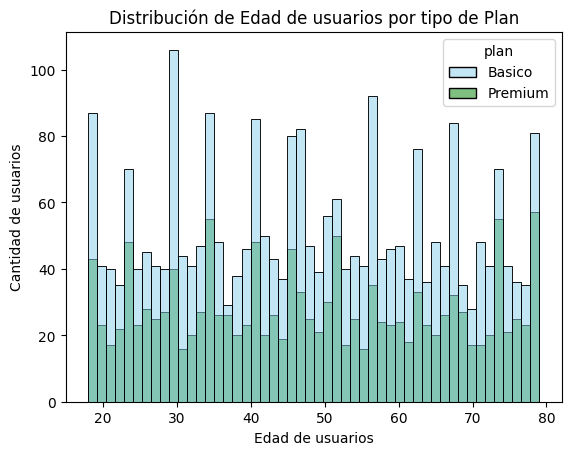

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', bins=50, palette=['skyblue', 'green'])
plt.xlabel('Edad de usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de Edad de usuarios por tipo de Plan')
plt.show()


💡Insights:
- Distribución uniforme ó multimodal, manteniendo un promedio constante de entre 40 y 50 usuarios por año de edad. El Plan Básico predomina consistentemente sobre el Plan Premium en todas las edades.
- Existen diferentes grupos o nichos de clientes.
- La edad no es un factor determinante en la contratación de planes

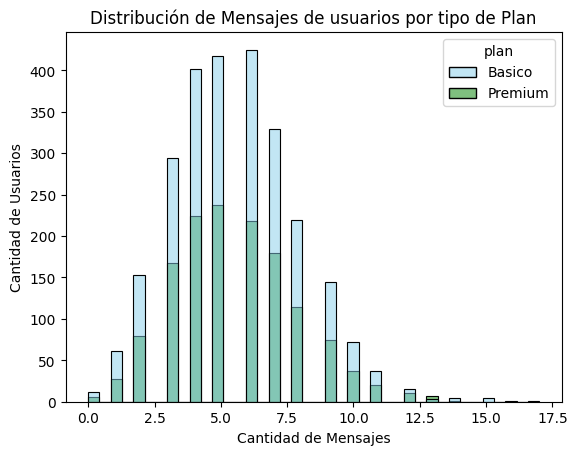

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=40, palette=['skyblue', 'green'])
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de Mensajes de usuarios por tipo de Plan')
plt.show()


💡Insights:
- La distribución se encuentra sesgada a la derecha por valores atípicos de 15 y 17 mensajes.
- En promedio se regitran 5 mensajes por usuario.
- No existe un patrón característico por tipo de plan, se mantienen las proporciones por plan (65% básico y 35% premium)

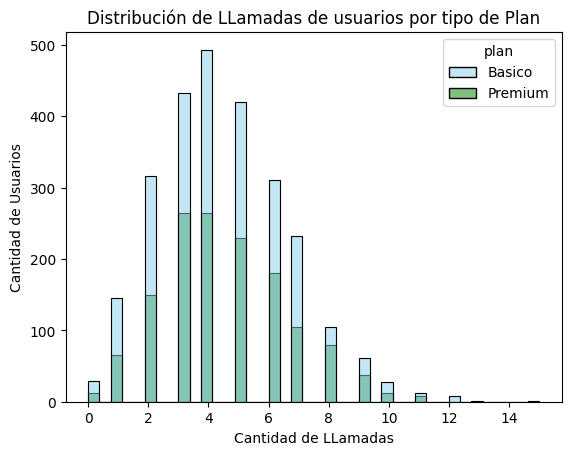

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=40, palette=['skyblue', 'green'])
plt.xlabel('Cantidad de LLamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución de LLamadas de usuarios por tipo de Plan')
plt.show()

💡Insights:
- Distribución con sesgo a la derecha por valores atípicos de 12 a 15 llamadas.
- El promedio de llamadas por usuario es de 4 a 5 llamadas.
- Las llamadas por tipo de plan se aprecian favorecidas para el plan premium que tienen mayor proporción que el plan básico.

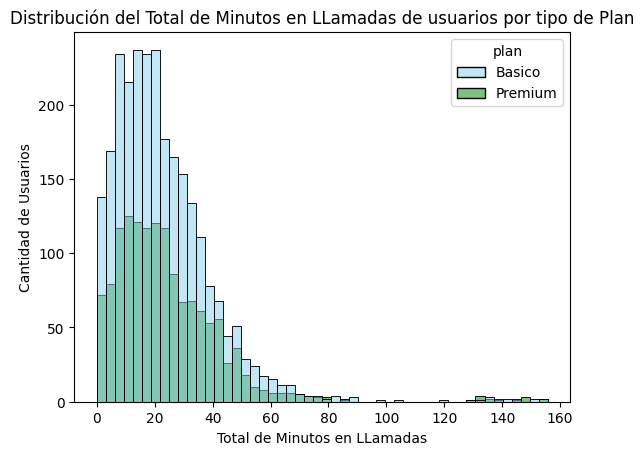

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=50, palette=['skyblue', 'green'])
plt.xlabel('Total de Minutos en LLamadas')
plt.ylabel('Cantidad de Usuarios')
plt.title('Distribución del Total de Minutos en LLamadas de usuarios por tipo de Plan')
plt.show()

💡Insights:
- Distribución con importante sesgo a la derecha por duraciones largas en llamadas desde 70 hasta 160 minutos (valores atípicos).
- Se aprecia una proporción similar a simple vista ya que ambos planes van cediendo conforme avanzan los minutos pero, a partir del minuto 40 se desploma el plan básico y el plan premium se mantiene de cierta forma, aunque después siguen decreciendo ambos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

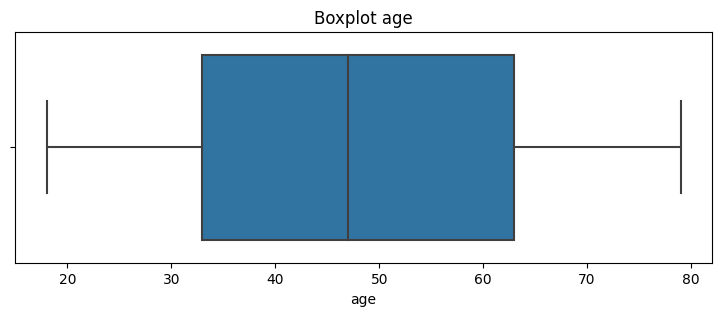

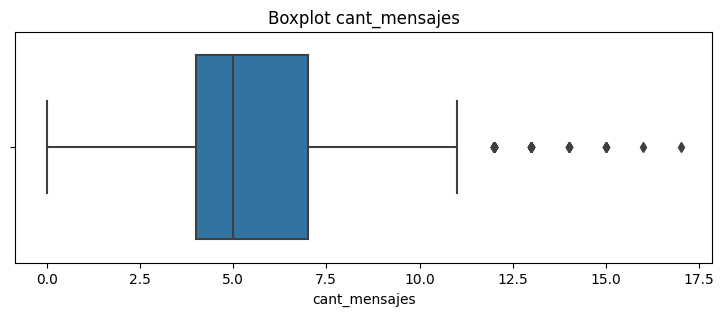

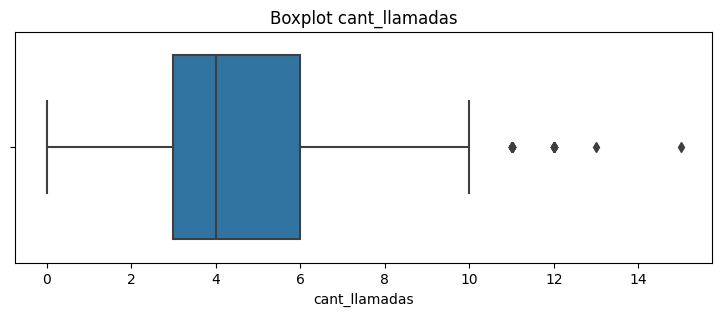

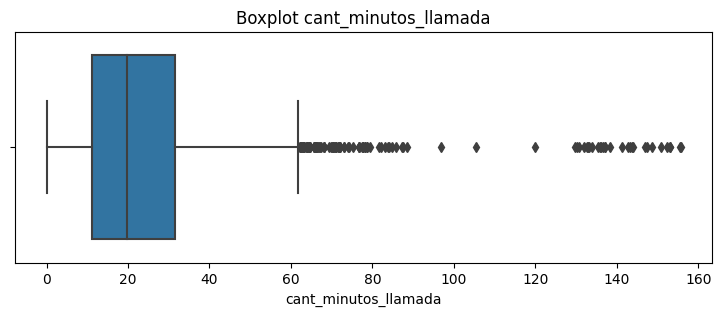

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers y los datos son simétricos. Edades concentradas entre 33 y 63 años con un valor medio de apróx. 47 años.
- cant_mensajes: Sí presenta outliers que representan de 12 hasta 17 mensajes atípicos. Caja azul muestra concentración entre 4 y 6 mensajes.
- cant_llamadas: Sí presenta outliers de 11 a 16 llamadas atípicas. La concentración define entre 3 y 6 llamadas.  
- cant_minutos_llamada: **Sí presenta gran cantidad de outliers en minutos de llamadas que van de 65 a 160 minutos. La mayoría gasta entre 11 y 31 minutos.**

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + (1.5 * IQR)

    cantidad_outliers = (user_profile[col] > upper).sum()

    print(f"Columna: {col}")
    print(f" -> Límite Superior (IQR): {upper:.2f}")
    print(f" -> Cantidad de usuarios atípicos: {cantidad_outliers}")
    print("-" * 40)

Columna: cant_mensajes
 -> Límite Superior (IQR): 11.50
 -> Cantidad de usuarios atípicos: 46
----------------------------------------
Columna: cant_llamadas
 -> Límite Superior (IQR): 10.50
 -> Cantidad de usuarios atípicos: 30
----------------------------------------
Columna: cant_minutos_llamada
 -> Límite Superior (IQR): 61.86
 -> Cantidad de usuarios atípicos: 109
----------------------------------------


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- En este proyecto de análisis, mantener los outliers será lo mejor ya que representan acciones reales de los clientes y se conserva la integridad de los datos.
- cant_mensajes, cant_llamadas y cant_minutos_llamada: mantener o no outliers, porqué? Será mejor mantener los outliers porque estos valores atípicos representan consumo de servicio que se traduce en uso de la infraestructura de ConnectaTel y representa dinero del negocio. Se requiere conocer el uso real para establecer estrategias comerciales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
# Se crea una función para la segmentación de clientes por uso

def clientes_por_uso(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']

    if mensajes < 5 and llamadas < 5:
        return 'Bajo uso'
    elif mensajes < 10 and llamadas < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile["grupo_uso"] = user_profile.apply(clientes_por_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:

# Crear columna grupo_edad
# Se crea una función para la segmentación de clientes por edad

def clientes_por_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'


user_profile["grupo_edad"] = user_profile.apply(clientes_por_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

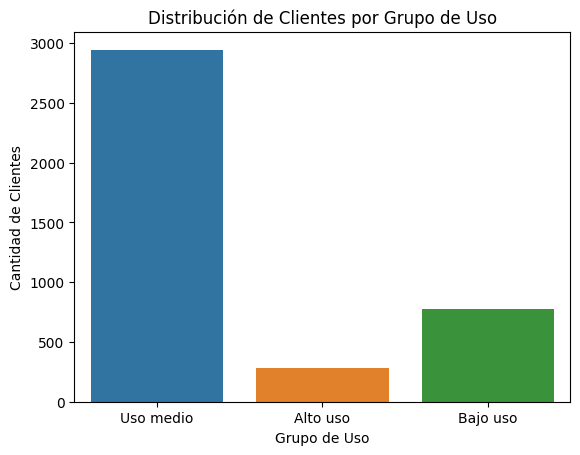

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.show()

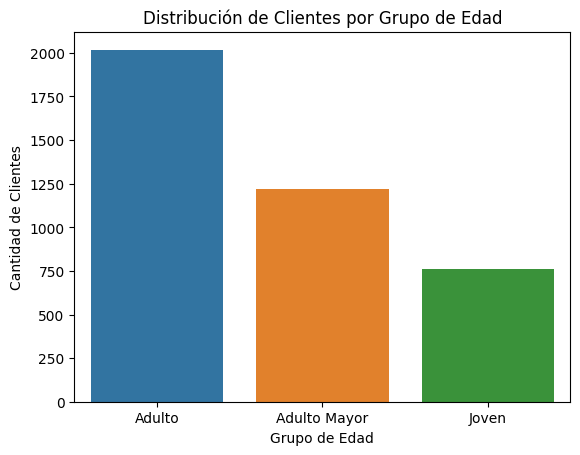

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [ ]:
# Cruzar segmentos de uso
cruce_segmentos = pd.crosstab(user_profile['grupo_uso'], user_profile['grupo_edad'])
cruce_segmentos

grupo_edad,Adulto,Adulto Mayor,Joven
grupo_uso,,,
Alto uso,154,74,51
Bajo uso,364,257,157
Uso medio,1500,891,552


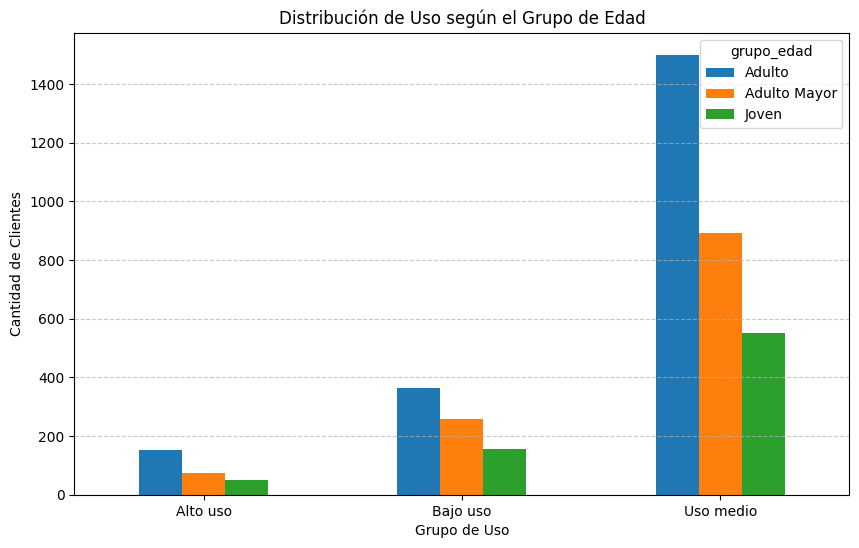

In [ ]:
# Visualización de los segmentos cruzados
cruce_segmentos.plot(kind='bar', figsize=(10, 6))

# Configurar títulos y etiquetas
plt.title('Distribución de Uso según el Grupo de Edad')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)  # Mantiene los nombres del eje X horizontales
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Agrega líneas de guía de fondo

# Mostrar el gráfico
plt.show()

In [ ]:

# Cruzar las ciudades con segmentos
cruce_ciudad_uso = pd.crosstab(user_profile['city'], user_profile["grupo_edad"])
cruce_ciudad_uso


grupo_edad,Adulto,Adulto Mayor,Joven
city,,,
Bogotá,408,248,152
CDMX,389,204,137
Cali,210,146,68
GDL,213,141,96
MTY,207,126,74
Medellín,307,181,128


In [ ]:
# Cruzar las ciudades con segmentos
cruce_ciudad_uso = pd.crosstab(user_profile['city'], user_profile["grupo_uso"])
cruce_ciudad_uso

grupo_uso,Alto uso,Bajo uso,Uso medio
city,,,
Bogotá,62,150,596
CDMX,48,146,536
Cali,30,77,317
GDL,28,94,328
MTY,24,81,302
Medellín,37,115,464


**Análisis por ciudad**

- El mercado principal (Adultos) está sólidamente distribuido, el valor del tiempo de vida del cliente de ConnectaTel está geográficamente blindado en las seis ciudades.
- Las estrategias comerciales que se apliquen no necesitan ser fragmentadas por ciudad, sino que se puede aplicar un despliegue corporativo unificado.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron valores nulos, sentinels y fechas fuera de rango en 2 datasets (users y usage) que fueron tratados para no afectar la calidad del análisis:
  1. 469 nulos en ‘city’ (11%) tratados como NaN por ser errores de sistema y 3,534 nulos en ‘churn_date’ (88%) no considerados por no ser objeto del análisis.
  2. 22,076 nulos en ‘duration’ (55%) y 17,896 nulos en ‘length’ (45%), tratados como NaN por naturaleza de negocio y por depender de una variable observable.
  3. 55 sentinels (-999) en ‘age’ reemplazados por la mediana para no deformar los grupos de edad y 96 sentinels (‘?’) en ‘city’ tratados como NaN por ser errores de sistema.
  4. 40 fechas fuera de rango (2026), tratadas como NaN por ser fallas de registro.

🔍 **Segmentos por Edad**
- Se identifican segmentos de clientes por edad (Joven, Adulto y Adulto Mayor) para detectar nichos:
  1. Adultos (30 a 60 años): Es el grupo mayoritario y el motor comercial de la empresa que genera el flujo de ingresos.  
  2. Adultos Mayores: Representan un sector leal de bajo riesgo de Churn (abandono) con alta actividad tradicional.
  3. Jóvenes: Es el grupo más rezagado en llamadas y mensajes tradicionales (552 usuarios). Su bajo interés sí representa un riesgo ya que está comprimiento el ingreso promedio por usuario (ARPU).

📊 **Segmentos por Nivel de Uso**
- Se crean segmentos por grupo de uso (Alto, Medio y Bajo) para conocer el perfil de consumo de llamadas y mensajes:
  1. Predomina el uso medio en Adultos (1500 usuarios) seguido de Adultos Mayores (891 usuarios):
     a) La oferta comercial actual de ConnectaTel satisface las necesidades de la población económicamente activa.
     b) Adultos son el segmento más eficiente ya que genera ingresos estables sin presionar los costos de capacidad operativa.
  3. Los Jóvenes (552 usuarios) quedan rezagados en estos servicios lo cual sugiere su interés en otros medios de comunicación.

➡️ esto sugiere que...
- Al concentrar el mayor volumen de usuarios y consistencia, los Adultos son el segmento más rentable para enfocar esfuerzos y mejoras en planes.
- Los Jóvenes que son el grupo débil, refuerza la necesidad de reestructurar la oferta comercial para elevar el valor de este nicho y optimizar los márgenes de contribución.

📈 **Patrones de Uso Extremo y Hallazgos**
- Tras aplicar gráficos Boxplot y método IQR (cant_mensajes, cant_llamadas, cant_minutos_llamada), se detectan outliers que son usuarios con consumo extremo en llamadas, minutos y mensajes, lo que refleja clientes con necesidades comerciales o de uso intensivo.
- Se optó por aislar su comportamiento mediante la segmentación de 'Alto uso' y evaluar el diseño de estrategias comerciales específicas que puedan absorber los costos operativos de la red de telecomunicaciones.

💡 **Recomendaciones**

- Crear planes enfocados en "Servicios Ilimitados" (ConnectaTel Business o Premium) a un mayor costo para absorber y rentabilizar a los usuarios outliers.
  

- Implementar una Política de Uso Justo en el plan básico para limitar consumos atípicos sin cobros sorpresa.
  

- Mejorar los beneficios del plan básico (más minutos y mensajes) para el segmento Adulto de acuerdo con su antigüedad, previniendo la migración de clientes ó abandono.
   
- Diseñar campañas específicas para el sector Joven incorporando planes con redes sociales incluidas o tarifas reducidas en llamadas y mensajes para incentivar su uso.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`